# Heart Disease Prediction Using Logistic Regression

This notebook implements a **Logistic Regression** model to predict whether a patient has heart disease.  
The dataset is preprocessed, balanced using **SMOTE**, and evaluated using different performance metrics and visualizations.

### Steps in this notebook
1. Load Data and Check Original Class Distribution  
2. Data Preprocessing  
3. Apply SMOTE to Balance Training Data  
4. Train Logistic Regression Model  
5. Evaluation and Visualizations

In [6]:
# Import required libraries for data handling, visualization, preprocessing, modeling, and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

# Set a clean plot style
sns.set_style("whitegrid")

## 1. Load Data and Check Original Class Distribution

In this section, the dataset is loaded into a pandas DataFrame.  
Then, the first few rows are displayed to understand the dataset structure.

In [7]:
# Load the dataset from the CSV file
df = pd.read_csv("heart.csv")

# Display the first 5 rows of the dataset
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Original Class Distribution

This graph shows the distribution of the target variable before applying SMOTE.

- **0** = No Heart Disease  
- **1** = Heart Disease  

This helps identify whether the dataset is imbalanced.

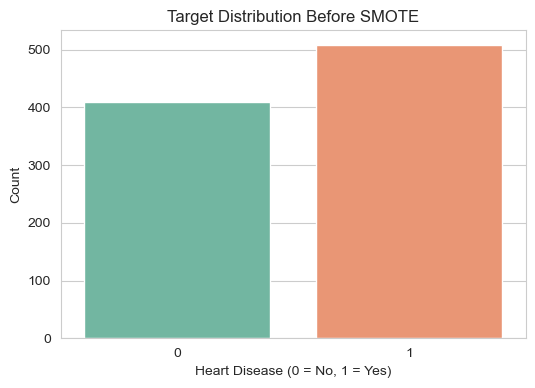

In [3]:
# Create a count plot to visualize the original class distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    x='HeartDisease',
    data=df,
    hue='HeartDisease',
    palette='Set2',
    legend=False
)

# Add chart title and axis labels
plt.title('Target Distribution Before SMOTE')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Display the graph
plt.show()

## 2. Data Preprocessing

Machine learning models require numerical input.  
Therefore, categorical features are converted into numerical form using **one-hot encoding**.

After that, the dataset is separated into:
- **X** = input features  
- **y** = target variable

In [8]:
# Convert categorical columns into numerical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Separate input features and target variable
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Display the shapes of feature matrix and target vector
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (918, 15)
Target Shape: (918,)


### Train-Test Split

The dataset is divided into:
- **80% training data**
- **20% testing data**

The `stratify=y` parameter is used to maintain the same class ratio in both training and testing sets.

In [9]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% of data is used for testing
    random_state=42,    # Ensures reproducible results
    stratify=y          # Preserves class distribution in train and test sets
)

# Display the shapes of the split datasets
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Data Shape: (734, 15)
Testing Data Shape: (184, 15)
Training Target Shape: (734,)
Testing Target Shape: (184,)


## 3. Apply SMOTE to Balance Training Data

Real-world datasets often suffer from class imbalance.  
To solve this problem, **SMOTE (Synthetic Minority Over-sampling Technique)** is applied to the training data.

SMOTE creates synthetic samples for the minority class, helping the model learn both classes more fairly.

In [10]:
# Create a SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display class counts before and after SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
HeartDisease
1    406
0    328
Name: count, dtype: int64

After SMOTE:
HeartDisease
1    406
0    406
Name: count, dtype: int64


### Class Distribution After SMOTE

This graph shows the distribution of the target variable after applying SMOTE to the training data.

A balanced class distribution improves fairness in model learning.

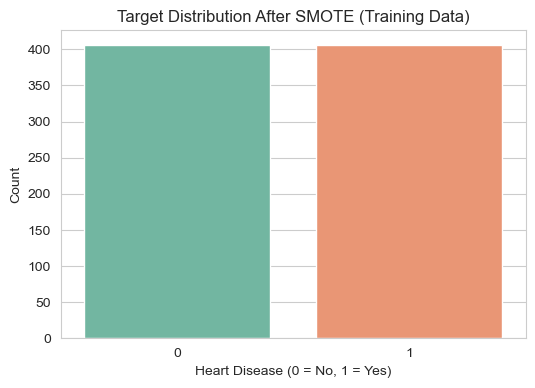

In [11]:
# Create a count plot to visualize the balanced class distribution after SMOTE
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette='Set2',
    legend=False
)

# Add chart title and axis labels
plt.title('Target Distribution After SMOTE (Training Data)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Display the graph
plt.show()

### Feature Scaling

Before training the Logistic Regression model, feature scaling is applied using **StandardScaler**.

This is important because Logistic Regression performs better when the input features are on a similar scale.

In [12]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the SMOTE training data and transform it
X_train_smote = scaler.fit_transform(X_train_smote)

# Transform the test data using the same scaler
X_test = scaler.transform(X_test)

## 4. Train Logistic Regression Model

In this step, the Logistic Regression model is trained using the balanced and scaled training dataset.

In [13]:
# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the scaled SMOTE training data
model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Make Predictions

After training the model, predictions are generated for the test dataset.

In [14]:
# Predict the target labels for the test set
y_pred = model.predict(X_test)

## 5. Evaluation and Visualizations

The model is evaluated using:
- **Accuracy**
- **Classification Report**
- **Confusion Matrix**
- **Accuracy Visualization**

These metrics help measure how well the model performs on unseen test data.

In [15]:
# Predict on training and testing data
y_train_pred = model.predict(X_train_smote)
y_test_pred = model.predict(X_test)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train_smote, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
difference = train_accuracy - test_accuracy

# Print training/testing accuracy and difference
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")
print(f"Difference:        {difference:.4f}")

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 0.8695
Testing Accuracy:  0.8804
Difference:        -0.0110

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        82
           1       0.87      0.92      0.90       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



### Confusion Matrix and Accuracy Graph

The confusion matrix shows how many predictions were:
- correctly predicted
- incorrectly predicted

The accuracy graph provides a simple visual summary of the model's overall performance.

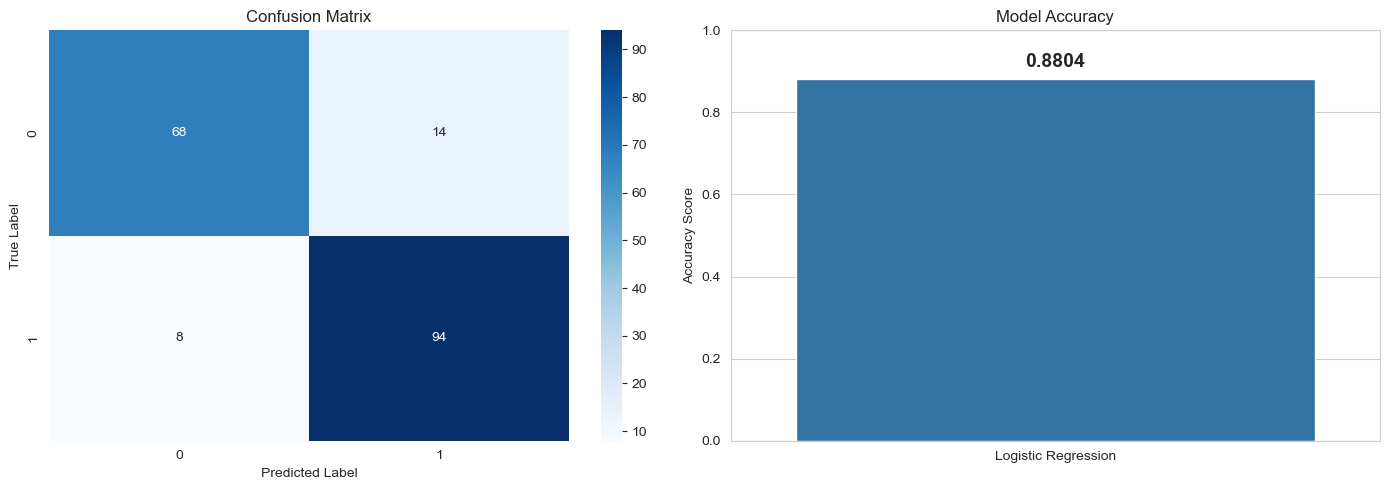

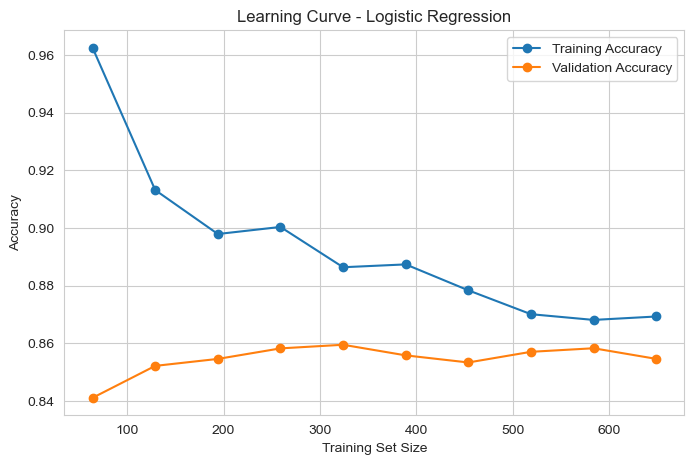

In [17]:
# Calculate confusion matrix using test predictions
cm = confusion_matrix(y_test, y_test_pred)

# Create figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# Plot testing accuracy as a bar chart
sns.barplot(
    x=['Logistic Regression'],
    y=[test_accuracy],
    ax=ax[1]
)

ax[1].set_ylim(0, 1)
ax[1].set_title('Model Accuracy')
ax[1].set_ylabel('Accuracy Score')

# Add accuracy value above the bar
ax[1].text(
    0,
    test_accuracy + 0.02,
    f'{test_accuracy:.4f}',
    ha='center',
    va='bottom',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Learning Curve
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model,
    X=X_train_smote,
    y=y_train_smote,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculate mean scores
train_scores_mean = train_scores.mean(axis=1)
validation_scores_mean = validation_scores.mean(axis=1)

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, validation_scores_mean, marker='o', label='Validation Accuracy')

plt.title('Learning Curve - Logistic Regression')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()